# Bearing Autoencoder — One AE, Per-Bearing Dynamic Threshold

**Key idea:**
- A **single** Conv1D autoencoder is trained once on healthy signals (MC nuisance).
- At deployment each physical bearing gets its **own** `AdaptiveTau` instance.
- The sliding window tracks μ and σ *locally* for that bearing → no cross-contamination.
- The z-score anchor `z_MC` is shared (derived from the simulator calibration set).

Steps:
1. Imports & seeds
2. Simulator
3. Generate dataset (healthy train/val + per-regime test)
4. Build & train autoencoder (once)
5. Reconstruction fidelity check
6. Per-regime MSE distributions
7. MC threshold calibration → derive `z_MC`
8. `AdaptiveTau` class — per-bearing sliding window
9. **Per-bearing experiment** — each bearing gets its own tracker
10. Window size sensitivity
11. Latent space PCA
12. Summary

## 0. Imports & seeds

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
tf.random.set_seed(42)
print('TF version:', tf.__version__)

TF version: 2.16.2


## 1. Simulator

In [3]:
from bearing_simulator import BearingSignalSimulator

sim = BearingSignalSimulator()
SIG_LEN = len(sim.t)
print(f'Signal length: {SIG_LEN} samples')

Signal length: 1200 samples


## 2. Generate dataset

- **Train / Val:** healthy only (MC) — the AE sees only M_healthy
- **Test:** all four regimes — never used for training

> Each test split is kept separate so we can simulate *independent bearings* later.

In [4]:
REGIMES = ['healthy', 'outer_race', 'inner_race', 'ball_fault']
COLORS  = ['#01696f', '#a12c7b', '#da7101', '#006494']
LABELS  = ['Healthy', 'Outer Race', 'Inner Race', 'Ball Fault']

N_TRAIN = 800   # healthy train
N_VAL   = 200   # healthy val  (also used for MC calibration)
N_TEST  = 200   # per regime for test

# ── Healthy train/val ──────────────────────────────────────────────────────
X_healthy = np.array([sim.sample('healthy', mc=True)
                       for _ in range(N_TRAIN + N_VAL)])
scaler = StandardScaler()
X_healthy_sc = scaler.fit_transform(X_healthy)

X_train = X_healthy_sc[:N_TRAIN, :, np.newaxis].astype('float32')
X_val   = X_healthy_sc[N_TRAIN:, :, np.newaxis].astype('float32')

# ── Test sets — one array PER regime ──────────────────────────────────────
# X_test_by_regime[i] shape: (N_TEST, SIG_LEN, 1)
X_test_by_regime = {}
for regime in REGIMES:
    sigs = np.array([sim.sample(regime, mc=True) for _ in range(N_TEST)])
    X_test_by_regime[regime] = scaler.transform(sigs)[:, :, np.newaxis].astype('float32')

print(f'Train: {X_train.shape}  Val: {X_val.shape}')
for k, v in X_test_by_regime.items():
    print(f'  Test [{k}]: {v.shape}')

Train: (800, 1200, 1)  Val: (200, 1200, 1)
  Test [healthy]: (200, 1200, 1)
  Test [outer_race]: (200, 1200, 1)
  Test [inner_race]: (200, 1200, 1)
  Test [ball_fault]: (200, 1200, 1)


## 3. Autoencoder architecture

```
Encoder: Conv1D(32) → Conv1D(64) → Conv1D(128) → Flatten → Dense(16)
Decoder: Dense → Reshape → Conv1DTranspose(128) → Conv1DTranspose(64) → Conv1DTranspose(1)
```
Trained **once**. All per-bearing logic lives in `AdaptiveTau`, not in the model.

In [5]:
LATENT_DIM = 16

def build_autoencoder(sig_len, latent_dim):
    inp = keras.Input(shape=(sig_len, 1), name='signal_in')
    x   = layers.Conv1D(32,  kernel_size=16, strides=2, padding='same', activation='relu')(inp)
    x   = layers.Conv1D(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(x)
    x   = layers.Conv1D(128, kernel_size=4,  strides=2, padding='same', activation='relu')(x)
    conv_shape = x.shape[1:]
    x   = layers.Flatten()(x)
    latent = layers.Dense(
        latent_dim,
        activity_regularizer=keras.regularizers.l1(1.5e-4),
        name='latent'
    )(x)
    y = layers.Dense(conv_shape[0] * conv_shape[1], activation='relu')(latent)
    y = layers.Reshape(conv_shape)(y)
    y = layers.Conv1DTranspose(128, kernel_size=4,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(32,  kernel_size=16, strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1D(1, kernel_size=1, padding='same', activation='linear', name='signal_out')(y)
    if y.shape[1] > sig_len:
        y = layers.Cropping1D((0, y.shape[1] - sig_len))(y)
    autoencoder = Model(inp, y,      name='bearing_autoencoder')
    encoder     = Model(inp, latent, name='encoder')
    return autoencoder, encoder

ae, encoder = build_autoencoder(SIG_LEN, LATENT_DIM)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
ae.summary()

2026-06-30 21:13:36.227768: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-30 21:13:36.227915: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-30 21:13:36.227923: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-30 21:13:36.228074: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-30 21:13:36.228084: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "bearing_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_in (InputLayer)          │ (None, 1200, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 600, 32)        │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 300, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 150, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │       307,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19200)          │       326,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 300, 128)       │        65,664 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 600, 64)        │        65,600 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 1200, 32)       │        32,800 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ signal_out (Conv1D)             │ (None, 1200, 1)        │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,601 (3.23 MB)

 Trainable params: 847,601 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training (healthy only — done once)

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1
    ),
]

history = ae.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100, batch_size=32,
    callbacks=callbacks, verbose=1,
)

Epoch 1/100


2026-06-30 21:13:37.196618: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.6965 - val_loss: 0.3075 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2033 - val_loss: 0.1419 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1312 - val_loss: 0.1150 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1027 - val_loss: 0.0945 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0879 - val_loss: 0.0837 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0795 - val_loss: 0.0753 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0742 - val_loss: 0.0733 - learning_rate: 0.0010
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0715 - val_loss: 0.0718 - learning_rate: 0.0010
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0700 - val_loss: 0.0705 - learning_rate: 0.0010
Epoch 10/100
25/25 ━━━

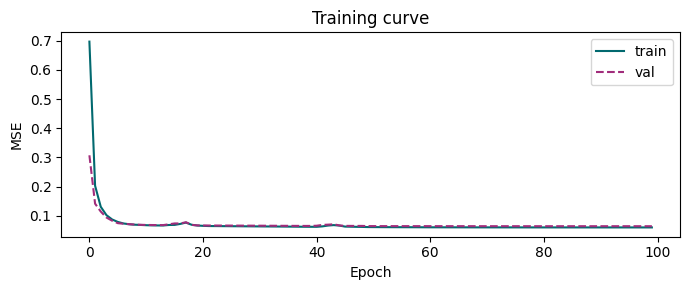

In [7]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history.history['loss'],     color='#01696f', label='train')
ax.plot(history.history['val_loss'], color='#a12c7b', ls='--', label='val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.set_title('Training curve')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Reconstruction fidelity (healthy val)

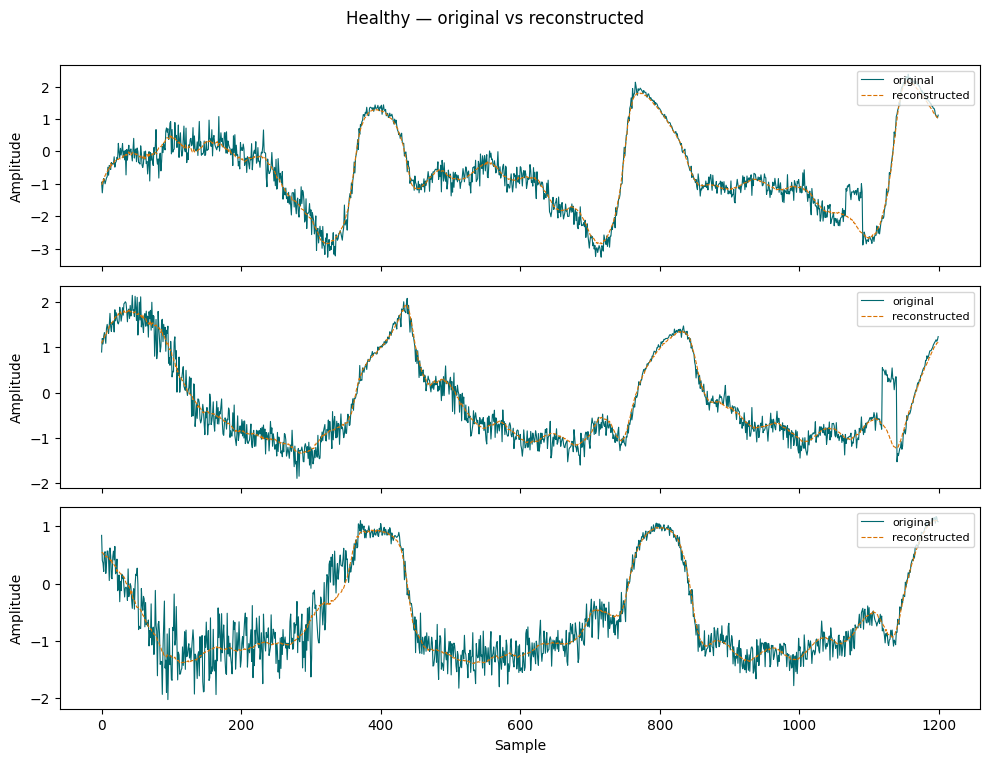

In [8]:
def per_sample_mse(model, X):
    Xr = model.predict(X, verbose=0)
    return np.mean((X[:, :, 0] - Xr[:, :, 0]) ** 2, axis=1)

n_show = 3
idx    = np.random.choice(len(X_val), n_show, replace=False)
preds  = ae.predict(X_val[idx], verbose=0)

fig, axes = plt.subplots(n_show, 1, figsize=(10, 2.5 * n_show), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(X_val[idx[k], :, 0], color='#01696f', lw=0.8, label='original')
    ax.plot(preds[k, :, 0],      color='#da7101', lw=0.8, ls='--', label='reconstructed')
    ax.set_ylabel('Amplitude'); ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Sample')
fig.suptitle('Healthy — original vs reconstructed', y=1.01)
plt.tight_layout(); plt.show()

## 6. Per-regime MSE distributions

Healthy signals should cluster at low MSE; fault regimes should drift higher.

Healthy       mean=0.0627  std=0.0244
Outer Race    mean=0.2916  std=0.0972
Inner Race    mean=0.4969  std=0.1824
Ball Fault    mean=0.1941  std=0.0597


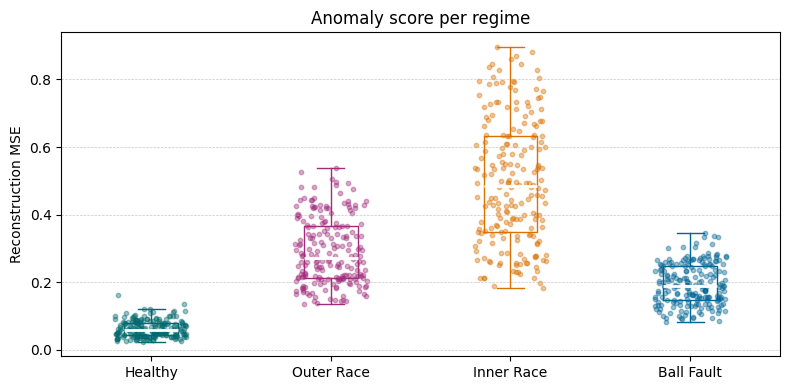

In [9]:
mse_per_regime = {r: per_sample_mse(ae, X_test_by_regime[r]) for r in REGIMES}

for r, label in zip(REGIMES, LABELS):
    m = mse_per_regime[r]
    print(f'{label:12s}  mean={m.mean():.4f}  std={m.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
for i, (regime, label, color) in enumerate(zip(REGIMES, LABELS, COLORS)):
    mse = mse_per_regime[regime]
    ax.scatter(
        np.full_like(mse, i) + np.random.uniform(-0.2, 0.2, len(mse)),
        mse, alpha=0.4, s=10, color=color, label=label)
    ax.boxplot(mse, positions=[i], widths=0.3,
               boxprops=dict(color=color), whiskerprops=dict(color=color),
               capprops=dict(color=color), medianprops=dict(color='white', lw=2),
               flierprops=dict(marker=''))
ax.set_xticks(range(len(REGIMES))); ax.set_xticklabels(LABELS)
ax.set_ylabel('Reconstruction MSE'); ax.set_title('Anomaly score per regime')
plt.grid(axis='y', ls='--', lw=0.5, alpha=0.7)
plt.tight_layout(); plt.show()

## 7. MC threshold calibration → derive z_MC

From the **healthy val set** we compute the static reference threshold and the
z-score that encodes its statistical meaning:

$$z_{\text{MC}} = \frac{\tau_{\text{MC}} - \mu_{\text{MC}}}{\sigma_{\text{MC}}}$$

This z-score is **shared across all bearings** — it represents the desired
false-alarm rate on healthy operation.

MC calibration  μ=0.0633  σ=0.02362
τ_MC (98th pct) = 0.11925   →  z_MC = 2.36914


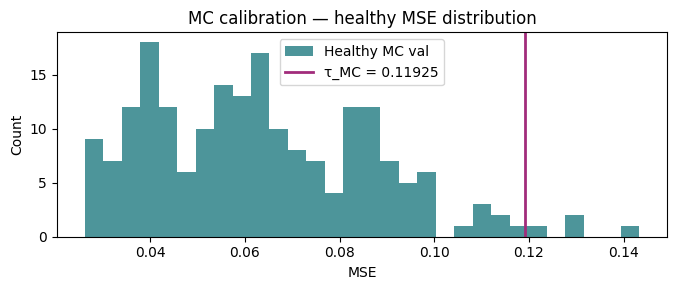

In [11]:
mse_mc = per_sample_mse(ae, X_val)   # healthy MC calibration set

mu_mc  = mse_mc.mean()
std_mc = mse_mc.std()

PERCENTILE = 98
tau_mc = np.percentile(mse_mc, PERCENTILE)
z_mc   = (tau_mc - mu_mc) / std_mc

print(f'MC calibration  μ={mu_mc:.4f}  σ={std_mc:.5f}')
print(f'τ_MC ({PERCENTILE}th pct) = {tau_mc:.5f}   →  z_MC = {z_mc:.5f}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(mse_mc, bins=30, color='#01696f', alpha=0.7, label='Healthy MC val')
ax.axvline(tau_mc, color='#a12c7b', lw=2, label=f'τ_MC = {tau_mc:.5f}')
ax.set_xlabel('MSE'); ax.set_ylabel('Count')
ax.set_title('MC calibration — healthy MSE distribution')
ax.legend(); plt.tight_layout(); plt.show()

## 8. AdaptiveTau — per-bearing sliding window

One instance per physical bearing. Each instance:
- Maintains its own rolling buffer of MSE values.
- Computes μ_t and σ_t locally.
- Applies **τ_t = μ_t + z_MC · σ_t** (shared z, local scale).
- Updates the buffer **only** with non-anomalous samples → no contamination.
- Can be pre-seeded with the MC val distribution for a warm, meaningful start.

```
bearing_A  →  AdaptiveTau(z_mc, window_size=WINDOW_SIZE)
bearing_B  →  AdaptiveTau(z_mc, window_size=WINDOW_SIZE)   # independent!
bearing_C  →  AdaptiveTau(z_mc, window_size=WINDOW_SIZE)
```

In [10]:
# ── Hyperparameter ──────────────────────────────────────────────────────────
WINDOW_SIZE = 200   # <-- main tuning knob; try 100 / 200 / 500


class AdaptiveTau:
    """
    Per-bearing sliding-window threshold estimator.

    Parameters
    ----------
    z_mc        : float  – shared z-score from MC calibration
    window_size : int    – rolling buffer length (healthy samples only)
    warmup      : int    – min samples before using dynamic τ; static τ_mc used before
    tau_init    : float  – static fallback during warm-up (defaults to tau_mc)
    """
    def __init__(self, z_mc: float, window_size: int = 200,
                 warmup: int = 50, tau_init: float = None):
        self.z_mc        = z_mc
        self.window_size = window_size
        self.warmup      = warmup
        self.tau_init    = tau_init
        self._buf        = deque(maxlen=window_size)

    def seed(self, mse_array: np.ndarray):
        """Pre-fill buffer with known-healthy values (e.g. MC val set)."""
        for v in mse_array[-self.window_size:]:
            self._buf.append(float(v))

    def update(self, mse_value: float):
        """
        Process one observation.
        Returns (mu_t, sigma_t, tau_t, is_anomaly).
        Buffer is updated only when the sample is NOT anomalous.
        """
        if len(self._buf) < max(2, self.warmup):
            tau   = self.tau_init if self.tau_init is not None else np.inf
            mu    = float(np.mean(list(self._buf))) if self._buf else 0.0
            sigma = float(np.std(list(self._buf)))  if len(self._buf) > 1 else 0.0
        else:
            arr   = np.array(self._buf)
            mu    = float(arr.mean())
            sigma = float(arr.std())
            tau   = mu + self.z_mc * sigma

        is_anomaly = bool(mse_value > tau)
        if not is_anomaly:
            self._buf.append(float(mse_value))
        return mu, sigma, tau, is_anomaly


print(f'AdaptiveTau defined  |  z_MC={z_mc:.2f}  default window={WINDOW_SIZE}')

AdaptiveTau defined  |  z_MC=2.39  default window=200


## 9. Per-bearing experiment

We simulate **4 independent bearings** running in parallel:

| Bearing | Scenario | Stream |
|---------|----------|--------|
| A | Always healthy | 200 healthy samples |
| B | Outer-race fault develops | 100 healthy → 100 outer_race |
| C | Inner-race fault develops | 100 healthy → 100 inner_race |
| D | Ball fault develops | 100 healthy → 100 ball_fault |

Each bearing gets its **own** `AdaptiveTau` instance, seeded identically from `mse_mc`.

In [11]:
# ── Define bearing scenarios ─────────────────────────────────────────────────
# Each scenario: list of (regime, n_samples)
BEARINGS = {
    'Bearing A\n(always healthy)':      [('healthy',    200)],
    'Bearing B\n(outer-race fault)':     [('healthy',    100), ('outer_race', 100)],
    'Bearing C\n(inner-race fault)':     [('healthy',    100), ('inner_race', 100)],
    'Bearing D\n(ball fault)':           [('healthy',    100), ('ball_fault', 100)],
}

# ── Build streams and run per-bearing AdaptiveTau ────────────────────────────
bearing_results = {}

for bearing_name, scenario in BEARINGS.items():
    # build stream
    stream_X, stream_regime = [], []
    for regime, n in scenario:
        arr = X_test_by_regime[regime][:n]
        stream_X.extend(arr)
        stream_regime.extend([regime] * n)
    stream_X = np.array(stream_X)  # (N, SIG_LEN, 1)

    # compute MSE (batch — model is shared)
    stream_mse = per_sample_mse(ae, stream_X)

    # create a fresh AdaptiveTau for THIS bearing only
    tracker = AdaptiveTau(z_mc=z_mc, window_size=WINDOW_SIZE,
                          warmup=50, tau_init=tau_mc)
    tracker.seed(mse_mc)   # warm start from MC val

    mus, sigmas, taus, flags = [], [], [], []
    for val in stream_mse:
        mu_t, sig_t, tau_t, flag = tracker.update(val)
        mus.append(mu_t); sigmas.append(sig_t)
        taus.append(tau_t); flags.append(flag)

    bearing_results[bearing_name] = dict(
        mse=stream_mse,
        taus=np.array(taus),
        mus=np.array(mus),
        sigmas=np.array(sigmas),
        flags=np.array(flags),
        regime=stream_regime,
        scenario=scenario,
    )

# ── Print per-bearing metrics ─────────────────────────────────────────────────
print(f'{"Bearing":<30} {"FAR (healthy)":>16} {"DR (fault)":>12}')
print('-' * 60)
for bname, res in bearing_results.items():
    scenario = res['scenario']
    n_healthy = sum(n for r, n in scenario if r == 'healthy')
    n_fault   = sum(n for r, n in scenario if r != 'healthy')
    far = res['flags'][:n_healthy].sum() / n_healthy if n_healthy else float('nan')
    dr  = res['flags'][n_healthy:].sum() / n_fault   if n_fault   else float('nan')
    label = bname.replace('\n', ' ')
    far_str = f'{far:.3f} ({int(res["flags"][:n_healthy].sum())}/{n_healthy})'
    dr_str  = f'{dr:.3f} ({int(res["flags"][n_healthy:].sum())}/{n_fault})' if n_fault else 'N/A'
    print(f'{label:<30} {far_str:>16} {dr_str:>12}')

Bearing                           FAR (healthy)   DR (fault)
------------------------------------------------------------
Bearing A (always healthy)        0.030 (6/200)          N/A
Bearing B (outer-race fault)      0.040 (4/100) 1.000 (100/100)
Bearing C (inner-race fault)      0.040 (4/100) 1.000 (100/100)
Bearing D (ball fault)            0.040 (4/100) 0.910 (91/100)


/var/folders/8c/dj1mc34n41j8l5wb58xh_k100000gn/T/ipykernel_22071/1818303132.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


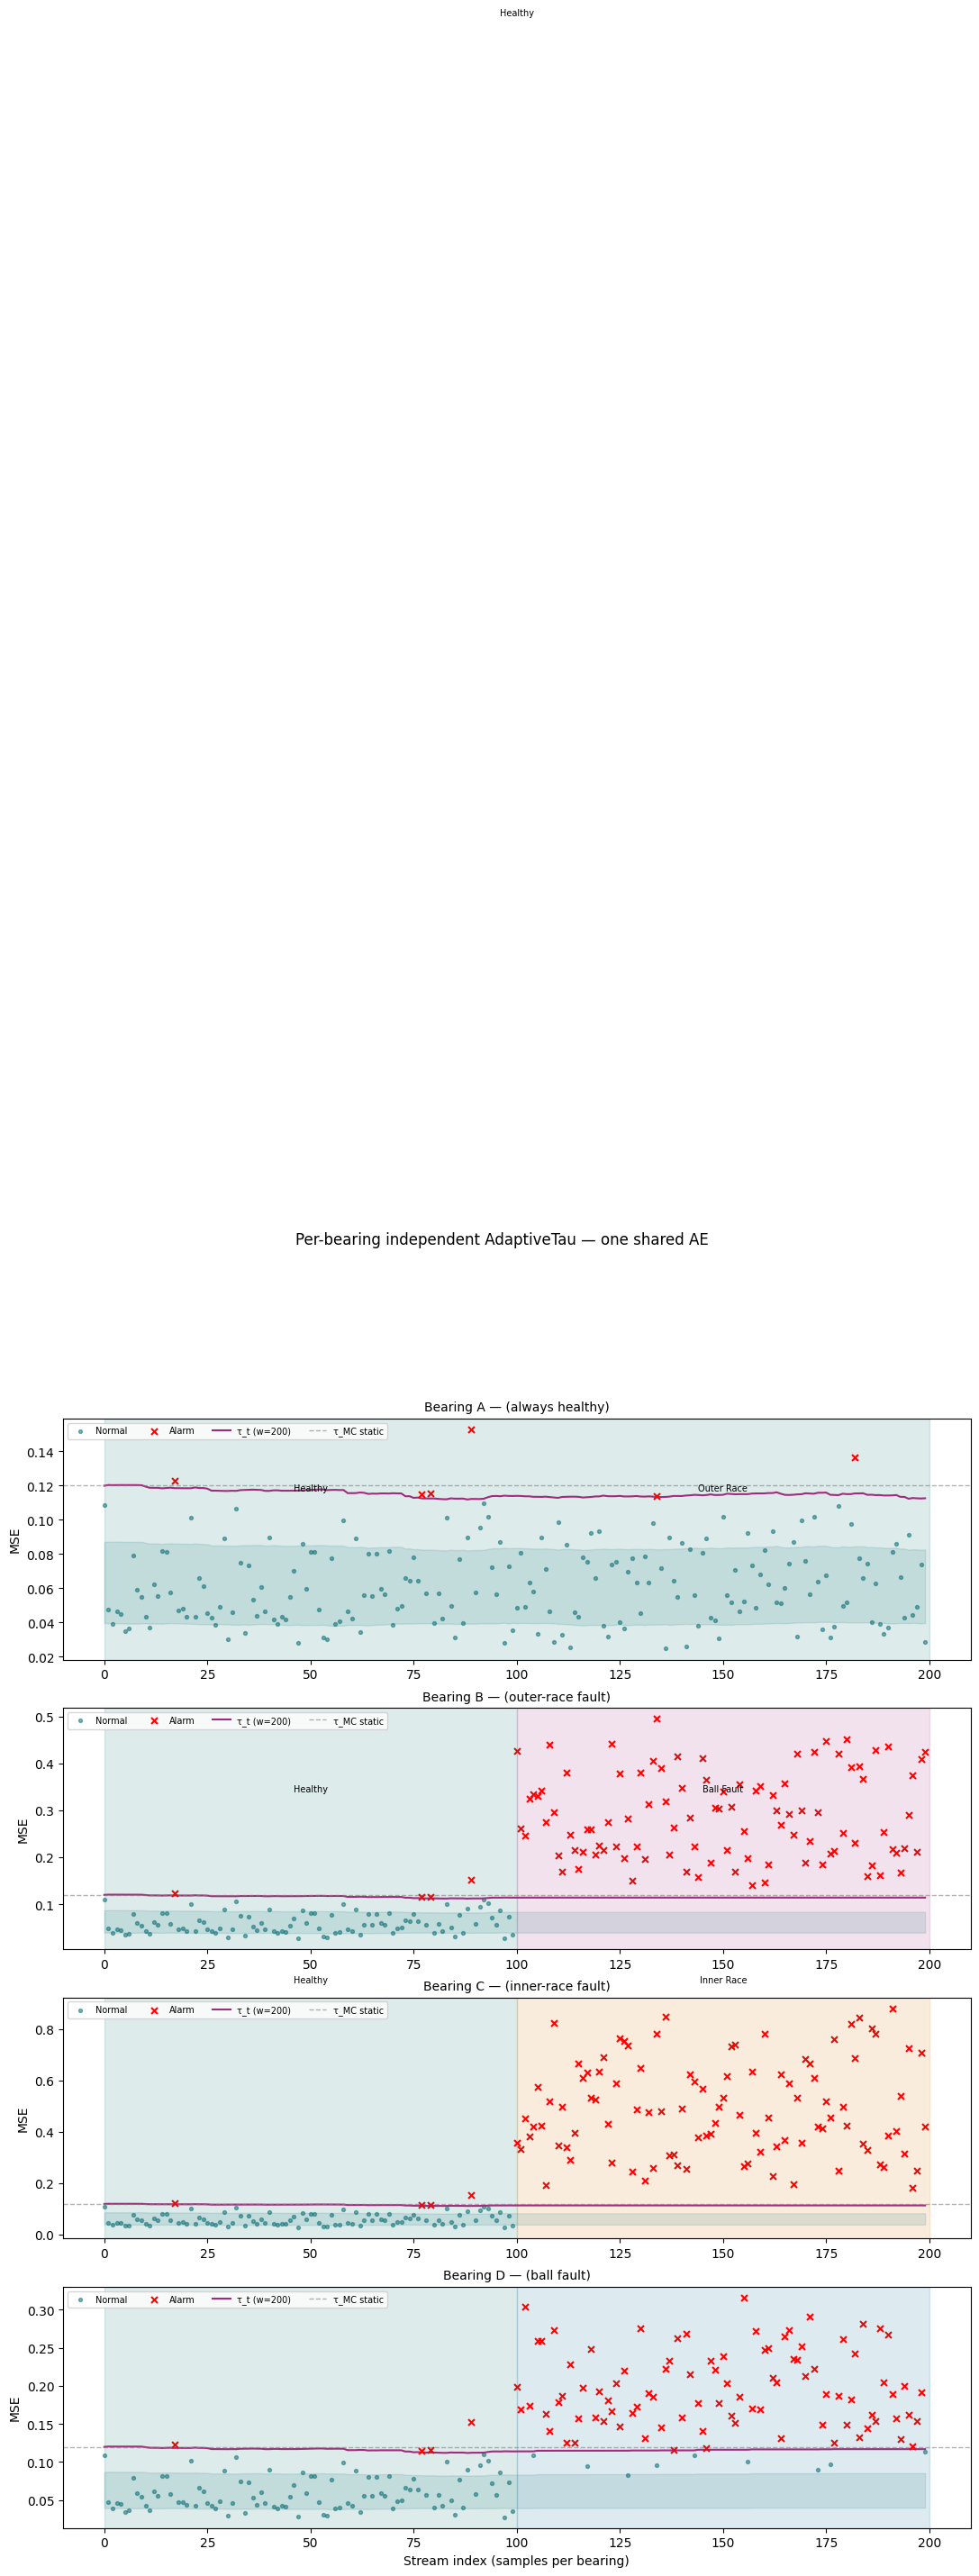

In [ ]:
fig, axes = plt.subplots(
    len(BEARINGS), 1,
    figsize=(13, 4.2 * len(BEARINGS) + 1.2),
    sharex=False,
)

for ax, (bname, res) in zip(axes, bearing_results.items()):
    t      = np.arange(len(res['mse']))
    flags  = res['flags']
    scenario = res['scenario']

    # shade background per segment
    cursor = 0
    for regime, n in scenario:
        color = COLORS[REGIMES.index(regime)] + '22'
        ax.axvspan(cursor, cursor + n, color=color, zorder=0)
        ax.text(
            cursor + n / 2,
            ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 0.98,
            LABELS[REGIMES.index(regime)],
            ha='center', fontsize=7,
        )
        cursor += n

    ax.scatter(t[~flags], res['mse'][~flags], s=8,  color='#01696f', alpha=0.5, label='Normal')
    ax.scatter(t[ flags], res['mse'][ flags], s=25, color='red', marker='x', zorder=5, label='Alarm')
    ax.plot(t, res['taus'], color='#a12c7b', lw=1.5, label=f'τ_t (w={WINDOW_SIZE})')
    ax.axhline(tau_mc, color='gray', lw=1, ls='--', alpha=0.6, label='τ_MC static')
    ax.fill_between(
        t,
        res['mus'] - res['sigmas'],
        res['mus'] + res['sigmas'],
        color='#01696f', alpha=0.12,
    )
    ax.set_title(bname.replace('\n', ' — '), fontsize=10)
    ax.set_ylabel('MSE')
    ax.legend(fontsize=7, loc='upper left', ncol=4)

axes[-1].set_xlabel('Stream index (samples per bearing)')
fig.suptitle('Per-bearing independent AdaptiveTau — one shared AE', fontsize=12, y=0.995)
fig.subplots_adjust(left=0.09, right=0.985, bottom=0.08, top=0.94, hspace=0.35)
plt.show()

## 10. Window size sensitivity

Sweep `WINDOW_SIZE` over several values and compare FAR vs Detection Rate
for the fault bearings (B, C, D). Results are averaged across the three fault scenarios.

window=   50  FAR=0.050  DR=0.950
window=  100  FAR=0.050  DR=0.977
window=  200  FAR=0.040  DR=0.970
window=  500  FAR=0.020  DR=0.960
window= 1000  FAR=0.020  DR=0.960


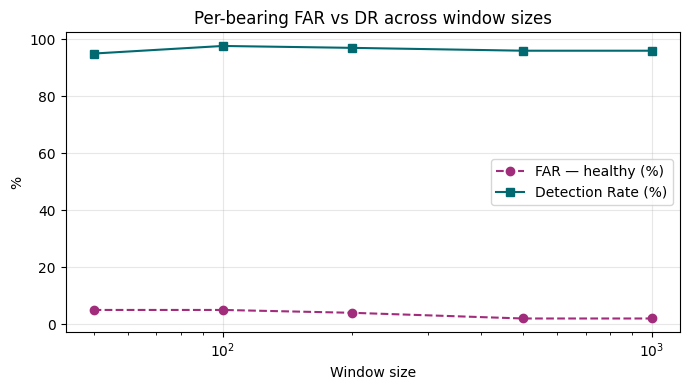

In [17]:
window_sizes = [50, 100, 200, 500, 1000]
sweep = []

fault_bearings = [
    ('outer_race', 100),
    ('inner_race', 100),
    ('ball_fault', 100),
]

for ws in window_sizes:
    far_list, dr_list = [], []
    for fault_regime, n_fault in fault_bearings:
        # stream: 100 healthy then 100 fault
        X_h = X_test_by_regime['healthy'][:100]
        X_f = X_test_by_regime[fault_regime][:n_fault]
        stream = np.concatenate([X_h, X_f], axis=0)
        mse    = per_sample_mse(ae, stream)

        tr = AdaptiveTau(z_mc=z_mc, window_size=ws,
                         warmup=min(ws // 4, 50), tau_init=tau_mc)
        tr.seed(mse_mc)
        flgs = np.array([tr.update(v)[3] for v in mse])
        far_list.append(flgs[:100].sum() / 100)
        dr_list.append(flgs[100:].sum()  / n_fault)

    sweep.append((ws, np.mean(far_list), np.mean(dr_list)))
    print(f'window={ws:5d}  FAR={np.mean(far_list):.3f}  DR={np.mean(dr_list):.3f}')

res_sw = np.array(sweep)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(res_sw[:, 0], res_sw[:, 1] * 100, 'o--', color='#a12c7b', label='FAR — healthy (%)')
ax.plot(res_sw[:, 0], res_sw[:, 2] * 100, 's-',  color='#01696f', label='Detection Rate (%)')
ax.set_xscale('log'); ax.set_xlabel('Window size'); ax.set_ylabel('%')
ax.set_title('Per-bearing FAR vs DR across window sizes')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Latent space geometry (PCA)

Even though the AE was trained only on healthy signals,
the 16-dim latent space should show some separation between regimes.

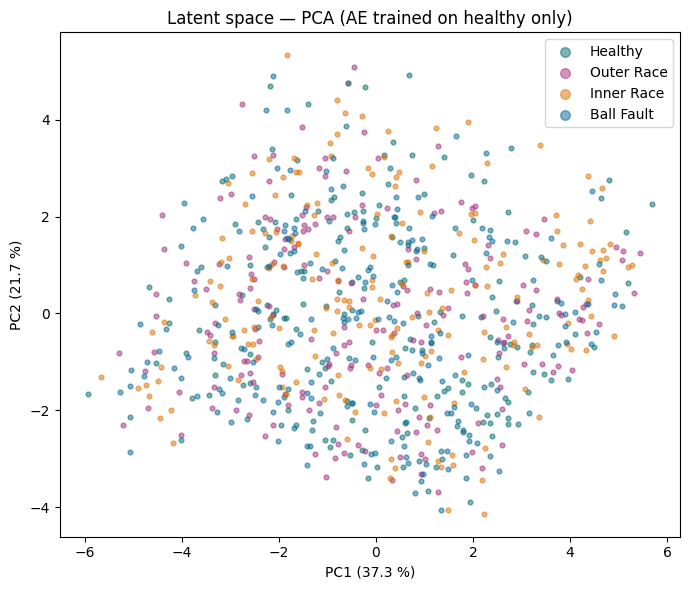

In [18]:
# Concatenate all regimes for PCA visualisation
X_all = np.concatenate([X_test_by_regime[r] for r in REGIMES], axis=0)
y_all = np.concatenate([[i] * N_TEST for i in range(len(REGIMES))])

Z_all = encoder.predict(X_all, verbose=0)
pca   = PCA(n_components=2)
Z2    = pca.fit_transform(Z_all)

fig, ax = plt.subplots(figsize=(7, 6))
for i, (label, color) in enumerate(zip(LABELS, COLORS)):
    mask = y_all == i
    ax.scatter(Z2[mask, 0], Z2[mask, 1], s=12, alpha=0.5, color=color, label=label)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)')
ax.set_title('Latent space — PCA (AE trained on healthy only)')
ax.legend(markerscale=2); plt.tight_layout(); plt.show()

## 12. Summary

| Component | Details |
|---|---|
| **AE** | Trained once on healthy MC signals — shared across all bearings |
| **z_MC** | Derived from healthy val set — shared, encodes desired FAR level |
| **AdaptiveTau** | One instance **per bearing** — independent buffer, μ_t, σ_t |
| **Buffer guard** | Anomalous samples never enter the buffer → no drift contamination |
| **Warm-up + seed** | Buffer pre-filled from MC val; τ_MC used as fallback until warm |
| **WINDOW_SIZE** | Main deployment knob — tune via Section 10 FAR/DR curve |

**Deployment pattern:**
```python
# At startup — one tracker per physical bearing
trackers = {
    'bearing_001': AdaptiveTau(z_mc, window_size=200, tau_init=tau_mc),
    'bearing_002': AdaptiveTau(z_mc, window_size=200, tau_init=tau_mc),
    ...
}
for name, tr in trackers.items():
    tr.seed(mse_mc)   # same warm start for all

# At runtime
mse = per_sample_mse(ae, new_signal[np.newaxis])[0]
mu, sigma, tau, alarm = trackers['bearing_001'].update(mse)
```